<h1 align="center"><b><code>EDA MEDICAL INSURANCE DATASET </code></b></h1>

## **`0. Import Library`**


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import math
import matplotlib.axes as Axes


## **`1. Load dataset and Check Input`**

In [ ]:
def read_dataset(file_path: str|Path, required_columns: list[str]|None = None, **kwargs) -> pd.DataFrame: 
    """
    Đọc dữ liệu từ file csv
    
    Args: 
        file_path: chứa đường dẫn đến file cần csv cần load lên
        require_columns: Danh sách các cột bắt buộc phải có trong dataset
        **kwargs: các tham số bổ sung được để truyền vào pandas.read_csv nếu cần
    
    Returns: 
        pd.DataFrame: trả về một dataframe chứ dữ liệu từ file csv
    """

    path = Path(file_path)

    # Kiểm tra đường dẫn có hợp lệ khôgn
    assert path.exists(), f"Không tìm thấy file."

    df = pd.read_csv(path, **kwargs)

    # Kiểm tra xem có cột nào bắt buộc có mà không có không
    if required_columns is not None: 
        missing_columns = [col for col in required_columns if col not in df.columns]
        assert not missing_columns, f"Dữ liệu bị thiếu các cột: {missing_columns}"
    
    print(f"Đọc dữ liệu thành công, kích thước: {df.shape}")
    
    df.columns = df.columns.str.strip().str.lower()

    print("DataFrame Head:")
    display(df.head(10)) 
    
    print("DataFrame Info:")
    df.info()

    return df

In [ ]:
file_path = "../data/Medical_Insurance_Cost.csv"
df = read_dataset(file_path)

Đọc dữ liệu thành công, kích thước: (1338, 7)
DataFrame Head:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


> Có thể thấy hiện tại chưa có hàng nào bị miss thông tin. Bây giờ ta check nhanh các bước cơ bản của dữ liệu trước để bước sau ta tiến hành preprocess

In [ ]:
df.duplicated().sum()

np.int64(1)

> Có dup một dòng duy nhất

In [ ]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

> Không có null. Bộ dữ liệu này khá sạch. Oke thử check mấy cột str xem sao. 

In [ ]:
for i in df.columns: 
    if df[i].dtype == 'str':
        print(f"- Các class mà cột {i} có: ")
        print(df[i].unique())
        print("-" * 30) 

- Các class mà cột sex có: 
<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
------------------------------
- Các class mà cột smoker có: 
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
------------------------------
- Các class mà cột region có: 
<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
------------------------------


> Được, bộ dữ liệu này rất là sạch, không có khác class là kì lạ hoặc trùng ý nghĩa. Vì các cột số đều phải dương, ta nên kiểm tra xem có cột numerical nào bị âm không 

In [ ]:
# Lọc ra các cột là số (int64 và float64)
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Kiểm tra xem từng cột có giá trị âm nào không
has_negative = (df_numeric < 0).any()

print("Kết quả kiểm tra giá trị âm theo từng cột:")
print(has_negative)

Kết quả kiểm tra giá trị âm theo từng cột:
age         False
bmi         False
children    False
charges     False
dtype: bool


> Không có cột nào có giá trị bị âm gây vô lý. Vậy quá trình preprocessing data của chúng ta sẽ khá là đơn giản. Có một điều cần lưu ý là vì bộ data này không có cột nào đóng vai trò là khóa chính, điều này có nghĩa là TA KHÔNG THỂ CHỨNG MINH LÀ CÁC HÀNG ĐÓ THẬT SỰ BỊ TRÙNG LẶP HAY LÀ THẬT SỰ HAI HÀNG GIỐNG NHAU. Tuy nhiên vì lý do không thể chứng minh và hơn nữa hàng lặp chỉ có một dòng khoảng 0.01% dữ liệu nên việc bỏ hay không cũng không quá đáng kể, ở đây ta có thể hoàn toàn bỏ bước điền Null và xóa duplicate.

## **`2. EDA`**

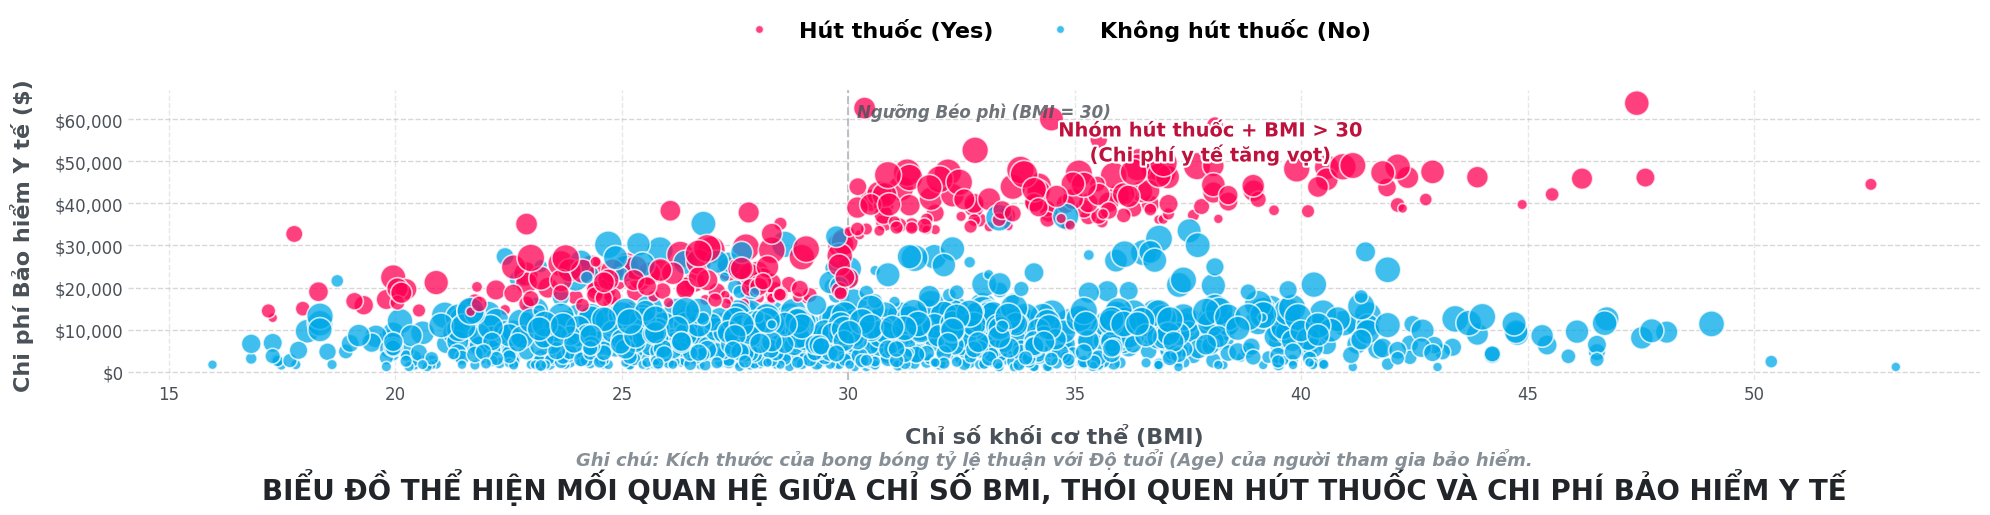

In [ ]:
import matplotlib.ticker as mtick
import matplotlib.patheffects as pe

smoker_colors = {
    'yes': '#FF0054',
    'no': '#00A8E8'   
}

fig, ax = plt.subplots(figsize=(20, 7))

bubble_sizes = (df['age'] / df['age'].max()) * 300

scatter = sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker',
    palette=smoker_colors,
    size='age',
    sizes=(50, 400),
    alpha=0.75,
    edgecolor='white',
    linewidth=1.2,
    ax=ax,
    zorder=3
)

ax.axvline(30, color='#ADB5BD', linestyle='--', linewidth=1.5, zorder=2, alpha=0.8)
ax.text(30.2, df['charges'].max() * 0.95, 'Ngưỡng Béo phì (BMI = 30)', color='#495057', 
        fontsize=12, fontweight='bold', style='italic', alpha=0.8)

outline_effect = [pe.withStroke(linewidth=3, foreground='white')]

ax.text(38, df['charges'].max() * 0.85, 
        'Nhóm hút thuốc + BMI > 30\n(Chi phí y tế tăng vọt)', 
        ha='center', va='center', fontsize=14, fontweight='900', color='#BE123C',
        path_effects=outline_effect, zorder=6)

sns.despine(left=True, bottom=True, top=True, right=True)

ax.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.5, zorder=0)
ax.xaxis.grid(True, linestyle='--', linewidth=1, alpha=0.3, zorder=0)

ax.tick_params(axis='both', length=0, labelsize=12, colors='#495057')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: f"${y:,.0f}"))

ax.set_xlabel('Chỉ số khối cơ thể (BMI)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)
ax.set_ylabel('Chi phí Bảo hiểm Y tế ($)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)

handles, labels = ax.get_legend_handles_labels()

smoker_idx = labels.index('smoker') if 'smoker' in labels else 0
yes_idx = labels.index('yes')
no_idx = labels.index('no')

custom_handles = [handles[yes_idx], handles[no_idx]]
custom_labels = ['Hút thuốc (Yes)', 'Không hút thuốc (No)']

ax.legend(handles=custom_handles, labels=custom_labels, title='', 
          bbox_to_anchor=(0.5, 1.1), loc='lower center', 
          ncol=2, frameon=False, prop={'weight': '600', 'size': 16})

ax.set_title('BIỂU ĐỒ THỂ HIỆN MỐI QUAN HỆ GIỮA CHỈ SỐ BMI, THÓI QUEN HÚT THUỐC VÀ CHI PHÍ BẢO HIỂM Y TẾ', 
             fontsize=20, fontweight='bold', color='#212529', pad=40, y=-0.6)

ax.text(0.5, -0.27, 'Ghi chú: Kích thước của bong bóng tỷ lệ thuận với Độ tuổi (Age) của người tham gia bảo hiểm.', 
        transform=ax.transAxes, ha='center', va='center', fontsize=13, fontweight='550', color='#868E96', style='italic')

plt.tight_layout()
plt.savefig('Medical_Insurance_Scatter.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

> Người có BMI quá lớn hoặc quá bé chưa chắc chi phí y tế lớn. Nhưng nếu người đó hút thuốc, việc BMI tăng sẽ dẫn đến chi phí y tế càng lớn một cách tuyến tính

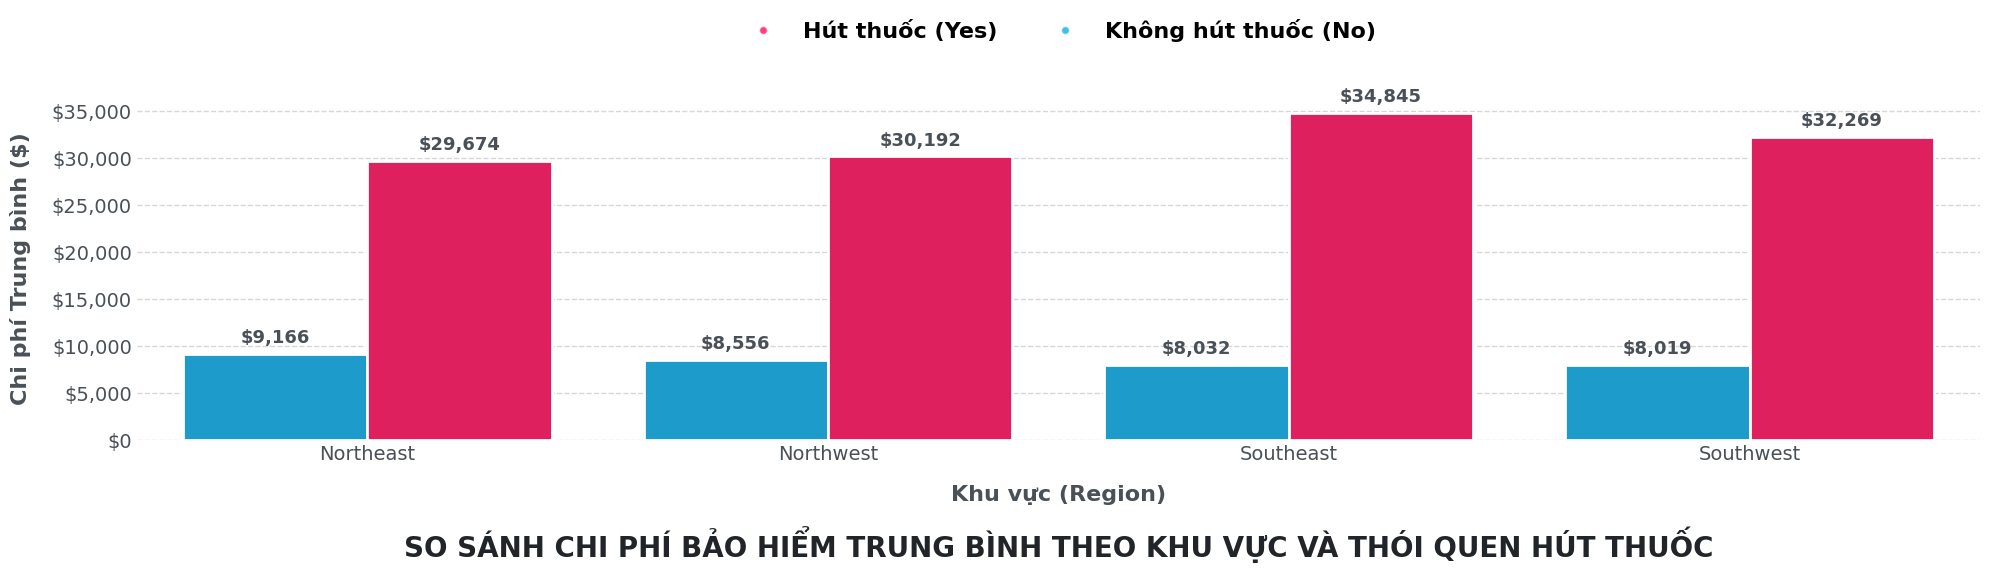

In [ ]:

fig2, ax2 = plt.subplots(figsize=(20, 7))

df_agg = df.groupby(['region', 'smoker'])['charges'].mean().reset_index()

sns.barplot(
    data=df_agg,
    x='region',
    y='charges',
    hue='smoker',
    palette=smoker_colors,
    ax=ax2,
    zorder=3,
    edgecolor='white',
    linewidth=2
)

for p in ax2.patches:
    height = p.get_height()
    if height > 0: 
        ax2.annotate(f'${height:,.0f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=13, fontweight='bold', color='#495057',
                    xytext=(0, 5), textcoords='offset points')

sns.despine(ax=ax2, left=True, bottom=True, top=True, right=True)

ax2.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.5, zorder=0)
ax2.xaxis.grid(False)

ax2.tick_params(axis='both', length=0, labelsize=14, colors='#495057')
ax2.set_xticks(ax2.get_xticks())
ax2.set_xticklabels([label.get_text().title() for label in ax2.get_xticklabels()])
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: f"${y:,.0f}"))

ax2.set_xlabel('Khu vực (Region)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)
ax2.set_ylabel('Chi phí Trung bình ($)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)

ax2.legend(handles=custom_handles, labels=custom_labels, title='', 
          bbox_to_anchor=(0.5, 1.1), loc='lower center', 
          ncol=2, frameon=False, prop={'weight': '600', 'size': 16})

ax2.set_title('SO SÁNH CHI PHÍ BẢO HIỂM TRUNG BÌNH THEO KHU VỰC VÀ THÓI QUEN HÚT THUỐC', 
             fontsize=20, fontweight='bold', color='#212529', pad=40, y=-0.5)

plt.tight_layout()
plt.savefig('Medical_Insurance_Bar.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(fig2)


> Khu vực dường như không phải là một yếu tố ảnh hưởng đến chi phí y tế. Tuy nhiên biểu đồ càng nhấn mạnh hơn vào việc hút thuốc càng nhiều chi phí ý tế có thể tăng gấp 3-5 lần 

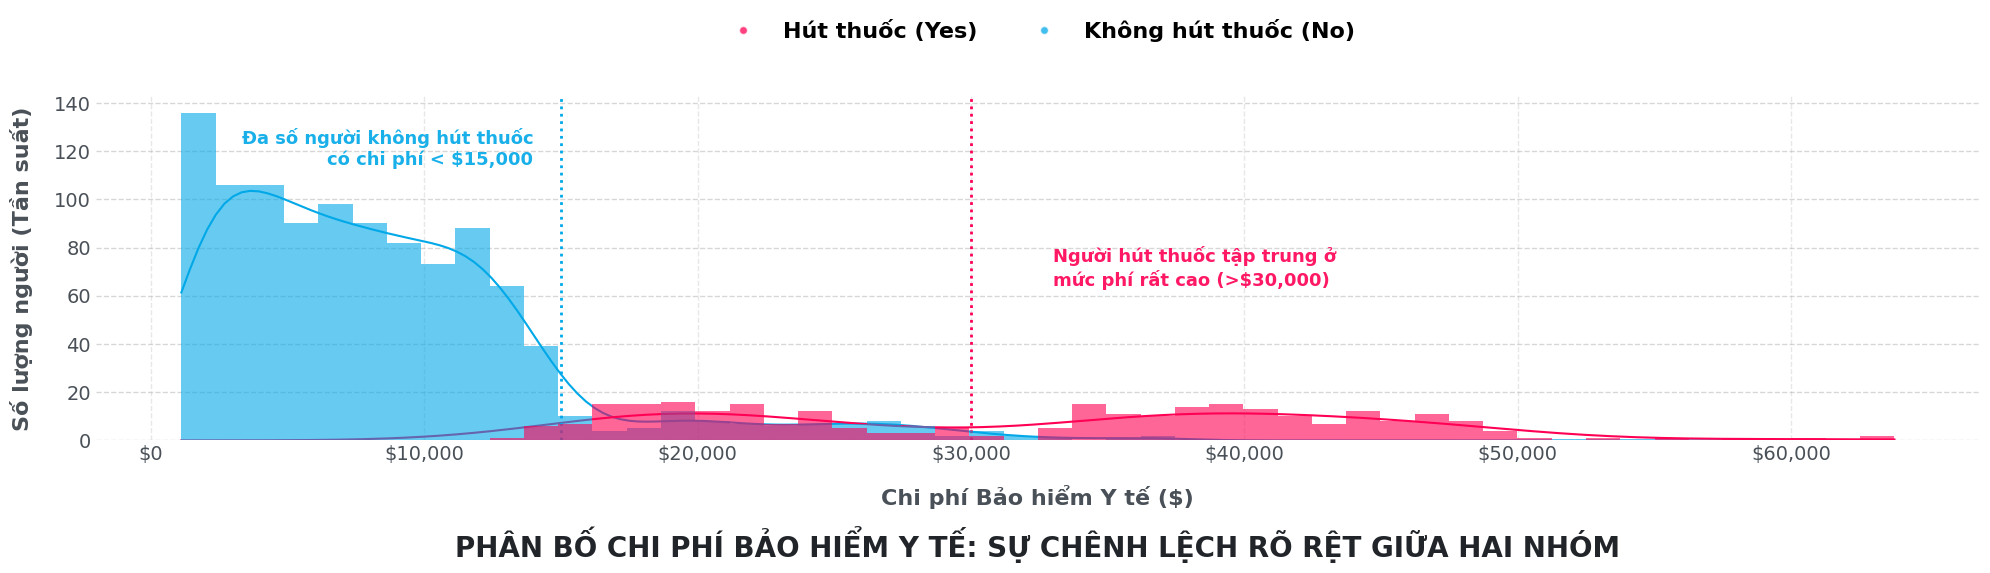

In [ ]:

fig3, ax3 = plt.subplots(figsize=(20, 7))

sns.histplot(
    data=df,
    x='charges',
    hue='smoker',
    palette=smoker_colors,
    kde=True,
    bins=50,
    alpha=0.6,
    linewidth=0,
    ax=ax3,
    zorder=3
)

sns.despine(ax=ax3, left=True, bottom=True, top=True, right=True)

ax3.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.5, zorder=0)
ax3.xaxis.grid(True, linestyle='--', linewidth=1, alpha=0.3, zorder=0)

ax3.tick_params(axis='both', length=0, labelsize=14, colors='#495057')

ax3.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"${x:,.0f}"))

ax3.set_xlabel('Chi phí Bảo hiểm Y tế ($)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)
ax3.set_ylabel('Số lượng người (Tần suất)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)

ax3.legend(handles=custom_handles, labels=custom_labels, title='', 
          bbox_to_anchor=(0.5, 1.1), loc='lower center', 
          ncol=2, frameon=False, prop={'weight': '600', 'size': 16})

ax3.axvline(15000, color='#00A8E8', linestyle=':', linewidth=2, zorder=2)
ax3.text(14000, ax3.get_ylim()[1]*0.8, 'Đa số người không hút thuốc\ncó chi phí < $15,000', 
        color='#00A8E8', fontsize=13, fontweight='bold', ha='right', alpha=0.9)
        
ax3.axvline(30000, color='#FF0054', linestyle=':', linewidth=2, zorder=2)
ax3.text(33000, ax3.get_ylim()[1]*0.45, 'Người hút thuốc tập trung ở\nmức phí rất cao (>$30,000)', 
        color='#FF0054', fontsize=13, fontweight='bold', ha='left', alpha=0.9)

ax3.set_title('PHÂN BỐ CHI PHÍ BẢO HIỂM Y TẾ: SỰ CHÊNH LỆCH RÕ RỆT GIỮA HAI NHÓM', 
             fontsize=20, fontweight='bold', color='#212529', pad=40, y=-0.5)

plt.tight_layout()
plt.savefig('Medical_Insurance_Dist.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(fig3)

> Biểu đồ này được vẽ nhằm nhấn mạnh hơn chi phí y tế khủng khiếp của việc hút thuốc

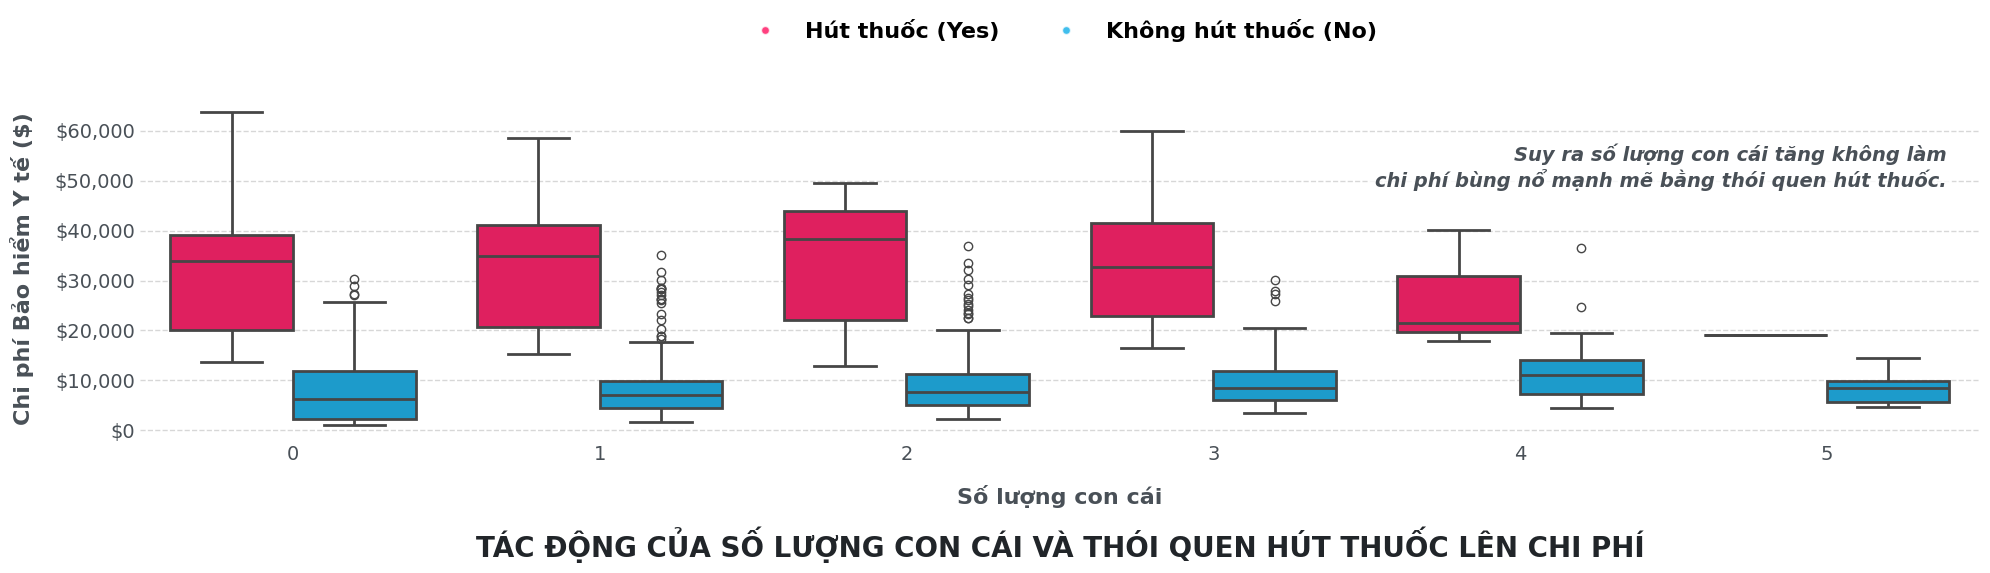

In [ ]:
fig4, ax4 = plt.subplots(figsize=(20, 7))

sns.boxplot(
    data=df,
    x='children',
    y='charges',
    hue='smoker',
    palette=smoker_colors,
    linewidth=2,
    fliersize=6,
    ax=ax4,
    zorder=3
)

sns.despine(ax=ax4, left=True, bottom=True, top=True, right=True)

ax4.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.5, zorder=0)
ax4.xaxis.grid(False)

ax4.tick_params(axis='both', length=0, labelsize=14, colors='#495057')

ax4.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: f"${y:,.0f}"))

ax4.set_xlabel('Số lượng con cái', fontsize=16, fontweight='bold', color='#495057', labelpad=15)
ax4.set_ylabel('Chi phí Bảo hiểm Y tế ($)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)

ax4.legend(handles=custom_handles, labels=custom_labels, title='', 
          bbox_to_anchor=(0.5, 1.1), loc='lower center', 
          ncol=2, frameon=False, prop={'weight': '600', 'size': 16})

ax4.text(ax4.get_xlim()[1]*0.98, df['charges'].max()*0.9, 
        'Suy ra số lượng con cái tăng không làm\nchi phí bùng nổ mạnh mẽ bằng thói quen hút thuốc.', 
        fontsize=14, fontweight='bold', color='#495057', style='italic', 
        ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax4.set_title('TÁC ĐỘNG CỦA SỐ LƯỢNG CON CÁI VÀ THÓI QUEN HÚT THUỐC LÊN CHI PHÍ', 
             fontsize=20, fontweight='bold', color='#212529', pad=40, y=-0.5)

plt.tight_layout()
plt.savefig('Medical_Insurance_Box.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(fig4)

> Số lượng con cái không làm ảnh hưởng đến chi phí y tế

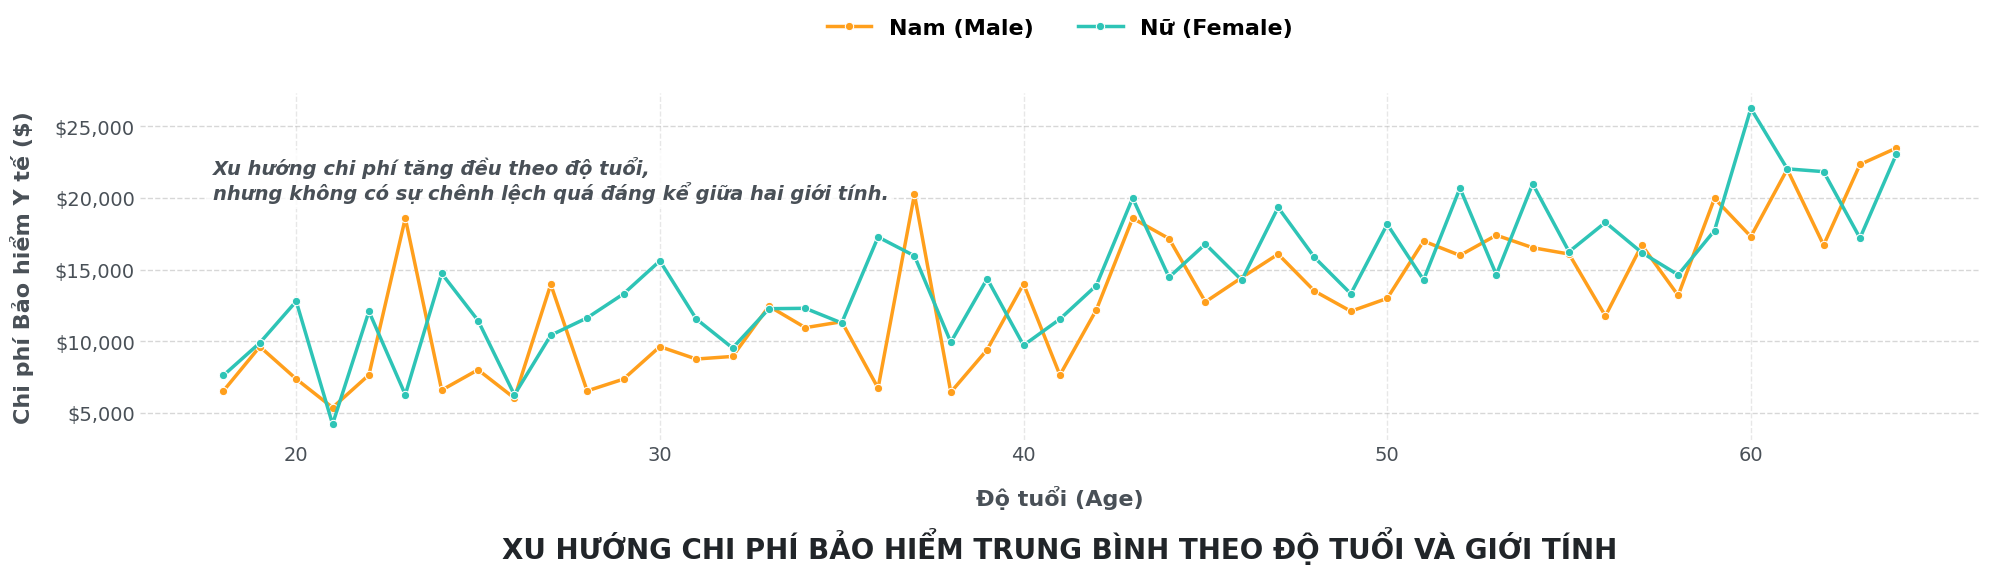

In [ ]:
sex_colors = {
    'male': '#2EC4B6',  
    'female': '#FF9F1C'  
}
fig5, ax5 = plt.subplots(figsize=(20, 7))
sns.lineplot(
    data=df,
    x='age',
    y='charges',
    hue='sex',
    palette=sex_colors,
    linewidth=2.5,
    errorbar=None, 
    marker='o',  
    markersize=6,
    ax=ax5,
    zorder=3
)

sns.despine(ax=ax5, left=True, bottom=True, top=True, right=True)

ax5.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.5, zorder=0)
ax5.xaxis.grid(True, linestyle='--', linewidth=1, alpha=0.3, zorder=0)

ax5.tick_params(axis='both', length=0, labelsize=14, colors='#495057')

ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: f"${y:,.0f}"))

ax5.set_xlabel('Độ tuổi (Age)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)
ax5.set_ylabel('Chi phí Bảo hiểm Y tế ($)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)

handles_sex, labels_sex = ax5.get_legend_handles_labels()
ax5.legend(handles=handles_sex, labels=['Nam (Male)', 'Nữ (Female)'], title='', 
          bbox_to_anchor=(0.5, 1.1), loc='lower center', 
          ncol=2, frameon=False, prop={'weight': '600', 'size': 16})

ax5.text(ax5.get_xlim()[0] + 2, df['charges'].max()*0.36, 
        'Xu hướng chi phí tăng đều theo độ tuổi,\nnhưng không có sự chênh lệch quá đáng kể giữa hai giới tính.', 
        fontsize=14, fontweight='bold', color='#495057', style='italic', 
        ha='left', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax5.set_title('XU HƯỚNG CHI PHÍ BẢO HIỂM TRUNG BÌNH THEO ĐỘ TUỔI VÀ GIỚI TÍNH', 
             fontsize=20, fontweight='bold', color='#212529', pad=40, y=-0.5)

plt.tight_layout()
plt.savefig('Medical_Insurance_Age_Sex.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(fig5)

> Người càng cao tuổi chi phí y tế càng lớn

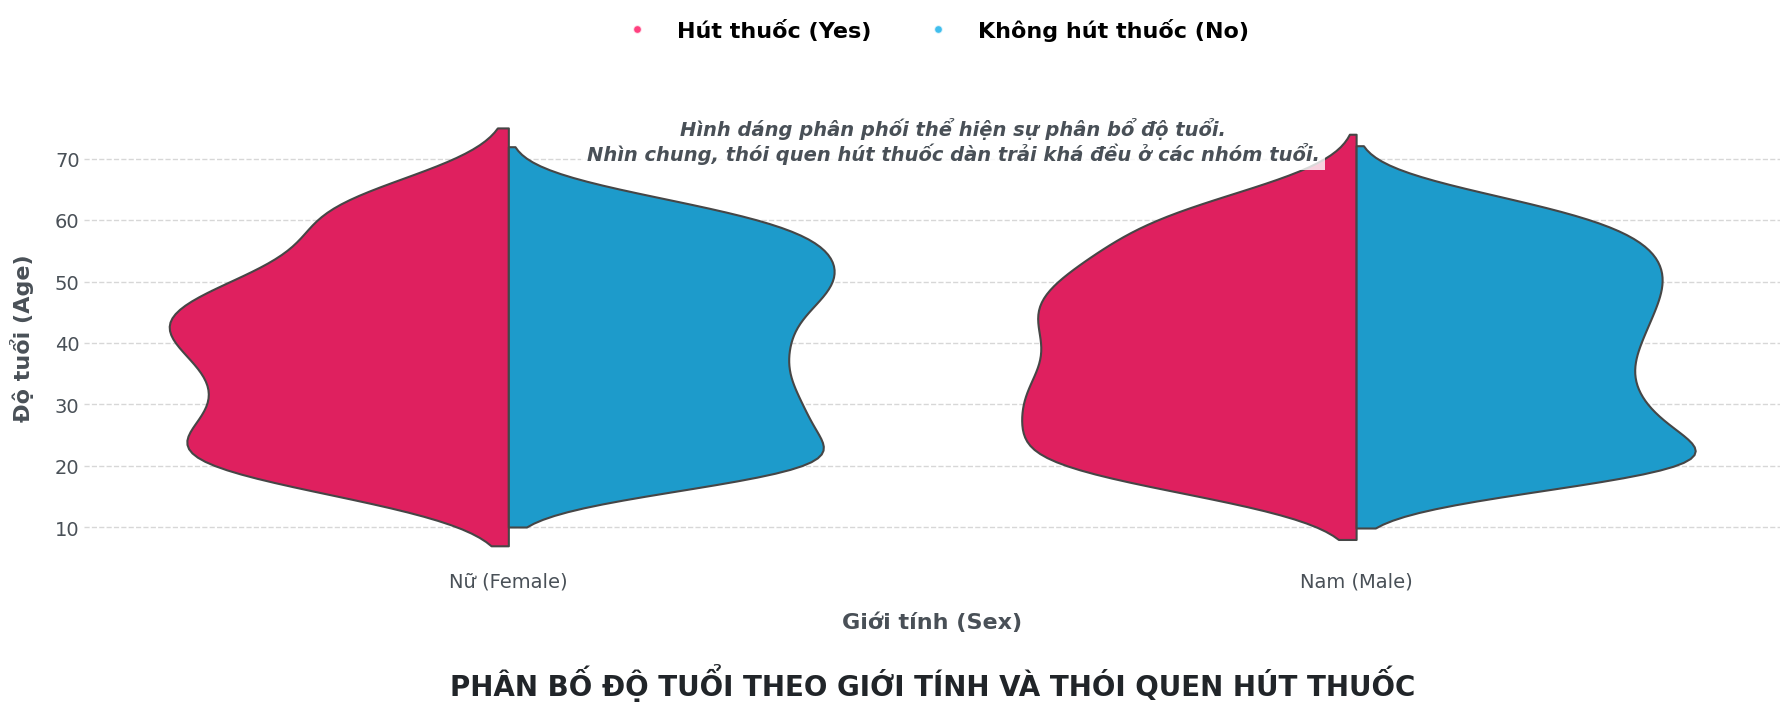

In [ ]:
fig6, ax6 = plt.subplots(figsize=(18, 8))

sns.violinplot(
    data=df,
    x='sex',
    y='age',
    hue='smoker',
    palette=smoker_colors,
    split=True,        
    inner='quartile',   
    linewidth=1.5,
    ax=ax6,
    zorder=3
)

sns.despine(ax=ax6, left=True, bottom=True, top=True, right=True)

ax6.yaxis.grid(True, linestyle='--', linewidth=1, alpha=0.5, zorder=0)
ax6.xaxis.grid(False)

ax6.tick_params(axis='both', length=0, labelsize=14, colors='#495057')

ax6.set_xticks(ax6.get_xticks())

ax6.set_xticklabels(['Nam (Male)' if label.get_text() == 'male' else 'Nữ (Female)' for label in ax6.get_xticklabels()])
ax6.set_xlabel('Giới tính (Sex)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)
ax6.set_ylabel('Độ tuổi (Age)', fontsize=16, fontweight='bold', color='#495057', labelpad=15)

ax6.legend(handles=custom_handles, labels=custom_labels, title='', 
          bbox_to_anchor=(0.5, 1.1), loc='lower center', 
          ncol=2, frameon=False, prop={'weight': '600', 'size': 16})

ax6.text(ax6.get_xlim()[1]*0.35, df['age'].max()*1.2, 
        'Hình dáng phân phối thể hiện sự phân bổ độ tuổi.\nNhìn chung, thói quen hút thuốc dàn trải khá đều ở các nhóm tuổi.', 
        fontsize=14, fontweight='bold', color='#495057', style='italic', 
        ha='center', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax6.set_title('PHÂN BỐ ĐỘ TUỔI THEO GIỚI TÍNH VÀ THÓI QUEN HÚT THUỐC', 
             fontsize=20, fontweight='bold', color='#212529', pad=40, y=-0.4)

plt.tight_layout()
plt.savefig('Medical_Insurance_Age_Sex_Smoker.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(fig6)

> Có thể thấy chi phí y tế bị ảnh hưởng rất lớn bởi việc người đó có hút thuốc hay không. Biểu đồ này nhằm xác nhận là độ tuổi có khiến người đó có hút thuốc nhiều hay không. Kết quả là không. Người ở bất kì độ tuổi nào đều có thể hút thuốc. 

> Sau khi đã phân tích bộ dữ liệu, ta tiến hành xử lý dữ liệu thử nghiệm với các model dự đoán 